In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch

## preprocess and embedding

In [3]:
from src.preprocessing import pp
from sklearn.model_selection import train_test_split
import scvi

In [4]:
control_key = "is_control"
condition_keys = "target_gene"
condition_rep_keys = "gene_embeddings"

In [5]:
filePath = './data/raw/adata_Training.h5ad'
adata = sc.read_h5ad(filePath)
# adata = adata[adata.obs.sample(frac=1, random_state=42).index].copy()
print(adata)

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'n_cells'


In [6]:
adata.obs['is_control'] = (adata.obs['target_gene'] == "non-targeting")
gene_list = adata[adata.obs['is_control']==False].obs['target_gene'].unique()
print(adata.obs[control_key].value_counts())

is_control
False    183097
True      38176
Name: count, dtype: int64


In [7]:
rng = np.random.default_rng(42) 
test_ratio = 0.1
gene_list = list(gene_list)
print(gene_list)

# 分层抽样 先验证分布内学习能力
adata_pert = adata[adata.obs["is_control"] == False].copy()
y = adata_pert.obs["target_gene"].astype(str).values
idx = np.arange(adata_pert.n_obs)
train_idx, test_idx = train_test_split(
    idx,
    test_size=test_ratio,
    random_state=42,
    stratify=y 
)
adata_train = adata_pert[train_idx].copy()
adata_test = adata_pert[test_idx].copy()
adata_control = adata[adata.obs["is_control"] == True].copy()
del adata, adata_pert

# 按基因分割 zero-shot
# n_test = max(1, int(len(gene_list) * test_ratio))
# test_gene = rng.choice(gene_list, size=n_test, replace=False).tolist()
# train_gene = [g for g in gene_list if g not in test_gene]
# adata_control = adata[adata.obs['is_control']==True].copy() # control的target_gene是non-targeting
# adata_train = adata[adata.obs["target_gene"].isin(train_gene)].copy() 
# adata_test = adata[adata.obs["target_gene"].isin(test_gene)].copy()
# del adata

['CHMP3', 'AKT2', 'SHPRH', 'TMSB4X', 'KLF10', 'TARBP2', 'KDM2B', 'SV2A', 'CLDN6', 'TCF3', 'ANTXR1', 'NDUFB6', 'TADA1', 'MED12', 'CAMSAP2', 'IDE', 'PRCP', 'WFS1', 'FOXH1', 'SMARCA4', 'TWF2', 'SAFB', 'POLB', 'TSC22D4', 'ACVR1B', 'PMS1', 'NISCH', 'INSIG1', 'DHCR24', 'MAP3K7', 'TMSB10', 'SMARCA5', 'STAG2', 'ZNF426', 'DNMT1', 'SSBP1', 'HIRA', 'USP22', 'PBX1', 'EID2', 'KAT2A', 'MAPKAPK2', 'SRC', 'HSBP1', 'MED13', 'ZNF593', 'TET1', 'KDR', 'EIF4B', 'SIX4', 'TFAM', 'MAST2', 'SMAGP', 'CAST', 'MTA1', 'ATP1B1', 'KIF20A', 'KIF1B', 'NCK2', 'XRCC4', 'RNF2', 'CASP3', 'HMGN1', 'GSK3B', 'RAB3B', 'MED13L', 'HMGB2', 'DHX36', 'IGF2R', 'HAT1', 'STAT6', 'ARID1A', 'CDCA2', 'SNCA', 'TRAM2', 'STAT1', 'TMBIM6', 'PMEL', 'DAXX', 'PRDM14', 'NREP', 'CREG1', 'METTL14', 'RAF1', 'RRM1', 'UQCRQ', 'BIRC2', 'IKBKG', 'LRPPRC', 'SDC1', 'ZNF714', 'CASP2', 'STX4', 'IRF3', 'CENPO', 'EWSR1', 'PLCB3', 'PHF14', 'MAU2', 'TAZ', 'DLG5', 'CLDN7', 'PAGR1', 'PTPN1', 'NDUFB4', 'KDM1A', 'UBE3C', 'TGFBR2', 'TRAPPC6A', 'MED24', 'METTL17', 

In [48]:
# sample_rep = "X_pca" 
sample_rep = "X_scVI" 
n_comps = 256
condition_rep_dict = pd.read_pickle("./data/processed/vcc_data_target_genes_embedding.pkl")
model_ref = None
if sample_rep == "X_scVI":
    adata_control.layers["counts"] = adata_control.X.copy()
    adata_train.layers["counts"] = adata_train.X.copy()
    if adata_test is not None:
        adata_test.layers["counts"] = adata_test.X.copy()

    scvi_save_path = f"./results/checkpoints/scvi_ncomps{n_comps}"
    if True:
        try:
            model_ref = scvi.model.SCVI.load(f"{scvi_save_path}_ref", adata=adata_control)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_ref = None 
        try:
            model_train = scvi.model.SCVI.load(f"{scvi_save_path}_train", adata=adata_train)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_train = None
        if adata_test is not None:
            try:
                model_test = scvi.model.SCVI.load(f"{scvi_save_path}_test", adata=adata_test)
            except (FileNotFoundError, OSError, ValueError) as e:
                model_test = None


INFO     File ./results/checkpoints/scvi_ncomps256_ref/model.pt already downloaded                                 
INFO     File ./results/checkpoints/scvi_ncomps256_train/model.pt already downloaded                               
INFO     File ./results/checkpoints/scvi_ncomps256_test/model.pt already downloaded                                


In [9]:
adata_control, adata_train, adata_test, model_ref, model_train, model_test = pp.process_to_embedding( 
    adata_control,
    adata_train,
    adata_test = adata_test,
    sample_rep = sample_rep,
    n_comps = n_comps,
    model_ref = model_ref,
    model_train = model_train,
    model_test = model_test,
    scvi_save_path = scvi_save_path,
    condition_rep_dict = condition_rep_dict
    )
if sample_rep == "X_pca":
    sample_rep_scaled = sample_rep + "_scaled" # 额 别忘了
else:
    sample_rep_scaled = sample_rep

projecting
Control Std: [0.01960167 0.89933723 0.01896451 0.02057352 0.9414619  0.02230126
 0.02193201 0.01990823 0.01986524 0.02604828 0.02118193 0.02140184
 0.02397425 0.02196544 0.02567282 0.02242487 0.99013567 0.02545183
 0.02536594 0.01974426 0.02276905 0.01982061 0.02139927 0.02059803
 0.02250244 0.02230342 0.02412182 0.02442769 0.8613878  0.02056006
 0.02083574 0.01986017 0.02092769 0.02696014 0.02002598 0.02414463
 0.02367306 0.9737915  0.02091322 0.9855472  0.8950636  0.0207935
 0.02109925 0.02253532 0.02046948 0.02101346 1.0407735  0.02859614
 0.02039842 1.1236582  1.2310073  0.02257051 0.874452   0.02259685
 0.0219794  0.02058103 0.02534064 0.02097135 0.02197127 0.02339635
 0.9485554  0.02559975 0.0203036  0.8775436  0.01979465 0.02323233
 0.01977947 0.02606316 0.02515039 0.02102    0.02345506 0.02788641
 0.02159272 0.9232859  0.8404968  0.02526959 0.02308516 0.02187531
 0.02559943 0.02204544 0.02538138 0.01917339 0.02079178 0.02469292
 0.02312729 0.02010509 1.236213   0.025

## training

In [15]:
from src.training import pre_compute_wfr_ot
from src.training import FNet,train
from torch.optim.lr_scheduler import CosineAnnealingLR

In [16]:
delta = 10
reg_m = 1
use_mini_batch_uot = False # mini_batch逻辑暂时还没有写
group_number = 3
save_path_train = f"./data/processed/vcc_ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_ncomps{n_comps}_train.pkl"
save_path_test = f"./data/processed/vcc_ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_ncomps{n_comps}_test.pkl"


# 记得修改抽样方法后重新计算
load_saved = True
if os.path.exists(save_path_train) and load_saved:
    ot_results_train = pd.read_pickle(save_path_train)
else:
    ot_results_train = pre_compute_wfr_ot(adata_control, 
                           adata_train, 
                           save_path_train, 
                           sample_rep=sample_rep_scaled, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw = False)

if os.path.exists(save_path_test) and load_saved:
    ot_results_test = pd.read_pickle(save_path_test)
else:
    ot_results_test = pre_compute_wfr_ot(adata_control, 
                           adata_test, 
                           save_path_test, 
                           sample_rep=sample_rep_scaled, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw=False)


In [61]:
# save_path = "./results/vcc/vcc_dvc_model.pt"
save_path = "./results/checkpoints/vcc_dvc"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
n_iterations = 30000

in_out_dim = adata_control.obsm[sample_rep_scaled].shape[1] # 256
hidden_dim_v = 1024 # dynamic network
hidden_dim_g = 512 
n_hiddens_v = 8
n_hiddens_g = 3
#condition
condition_dim = adata_train.obsm[condition_rep_keys].shape[1] # 1280
con_embedding_dim = 512  # condition encode dim
hidden_dim_con = 256 # condition network
#time
time_dim = 1024 # time embedding
time_embedding_dim = 256
hidden_dim_time = 256
bottle_dim = 256
activation = 'SiLU'

# 之前的设置
# in_out_dim = adata_control.obsm[sample_rep_scaled].shape[1]
# hidden_dim_v = 4096 # dynamic network
# hidden_dim_g = 2048 
# n_hiddens_v = 4
# n_hiddens_g = 2
# condition_dim = adata_train.obsm[condition_rep_keys].shape[1]
# con_embedding_dim = 512  # condition encode dim
# hidden_dim_con = 1024 # condition network
# time_dim = 1024 # time embedding
# time_embedding_dim = 256
# hidden_dim_time = 512
# bottle_dim = 1024
# activation = 'GELU'

model = FNet(in_out_dim, hidden_dim_v, n_hiddens_v, hidden_dim_g, n_hiddens_g, 
                 condition_dim, con_embedding_dim, hidden_dim_con, 
                 time_dim ,time_embedding_dim,hidden_dim_time, 
                 bottle_dim, activation)


load_model = False
if load_model:
    load_path = "./results/checkpoints/pca_30000_test1.pt"
    checkpoint = torch.load(load_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device) 
    model.eval() 
    print("load saved_model")

cuda


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = None
scheduler = CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=5e-6)
train.train_model(adata_control, adata_train, adata_test,
                ot_results_train, ot_results_test, 
                model.to(device),
                optimizer,
                scheduler = scheduler,
                n_iterations= n_iterations,
                batch_size_per_condition = 256,
                batch_size_condition = 10,
                sample_rep = sample_rep_scaled,
                condition_keys=condition_keys,
                condition_rep_keys = condition_rep_keys,
                device = device,
                save_path=save_path,
                eval_interval = 10)

# 我明白了 test_loss主要在于test_gloss 这是源于uot plan本身
# 这么说test的loss可能和train的loss缺乏一些可比性

/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/data.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices
/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/data.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices


data_loaded
data_loaded


Begin flow and growth matching...:   1%|▏         | 404/30000 [00:44<52:22,  9.42epoch/s, loss=0.280, vloss=0.257, gloss=0.023, test_loss=0.391, test_vloss=0.099, test_gloss=0.292]  

训练步数: 4990
最后一步 Loss: 0.025997
最后一步 vLoss: 0.020658
最后一步 gLoss: 0.005339
最后一步 test_Loss: 0.169171
最后一步 test_vLoss: 0.008655
最后一步 test_gLoss: 0.160517


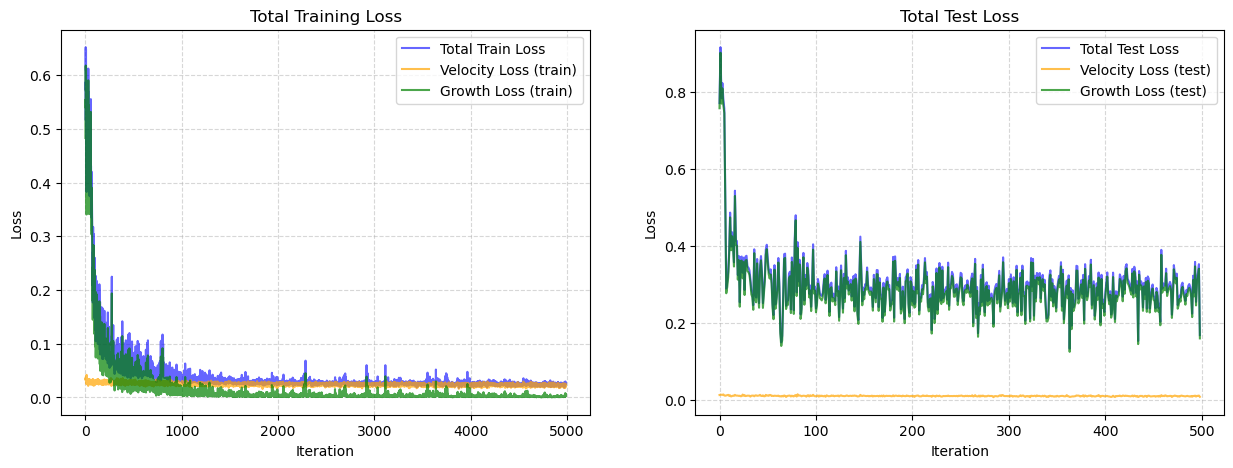

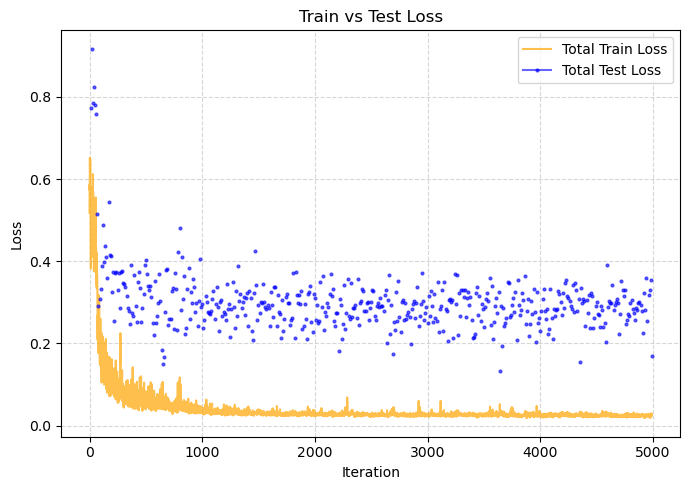

In [53]:
from src.evaluate import draw_loss
load_path = "./results/checkpoints/vcc_dvc_epoch_5000.pt"
draw_loss(load_path,eval_interval = 10,cut = 10)

## inference & evalutaion

In [54]:
from src.evaluate import run_batch_inference
target_genes = ['CDCA2', 'DHX36', 'TMSB10', 'KAT2A', 'PHF14', 'KLF10', 'KDM1A', 'STAT1', 'ACAT2', 'STX4', 'HMGB2', 'TADA1', 'MTA1', 'C1QBP']
# target_genes = ['CDCA2', 'DHX36', 'TMSB10']
                
n_particles = 5000
all_indices = np.arange(adata_control.n_obs)
rng = np.random.default_rng(42)
indices = rng.choice(all_indices, n_particles, replace=False) if n_particles < len(all_indices) else all_indices
adata_source = torch.tensor(adata_control.obsm[sample_rep_scaled][indices], dtype=torch.float32, device=device)

results_embedding = run_batch_inference(
    model=model,
    adata_source=adata_source,
    adata_conditions=adata_train,
    target_conditions=target_genes,
    condition_keys = condition_keys,
    embedding_key = condition_rep_keys,
    source_rep = sample_rep_scaled,
    n_steps = 50, # ode step
    device = device,
    random_seed = 42
)

100%|██████████| 14/14 [00:15<00:00,  1.09s/it]


In [55]:
from src.evaluate import batch_reconstruct_pca, batch_reconstruct_scvi

# 我们可以reconstruct出原始基因表达
# 这里 m应该咋用呢
if sample_rep == "X_pca":
    results_genes = batch_reconstruct_pca(
        inference_results=results_embedding,  
        ref_adata=adata_control        
    )
elif sample_rep == "X_scVI":
    batch_data = adata_control.obs['_scvi_batch'].values[indices]
    results_genes1 = batch_reconstruct_scvi(
        inference_results=results_embedding,
        scvi_model=model_ref,  # 传入模型
        target_library_size=1e4, # 输出将被标准化到 10,000 counts
        batch_idx = torch.tensor(adata_control.obs['_scvi_batch'].values[indices], dtype=torch.long, device=device).unsqueeze(1) # 如果希望都投射到第0个batch 可以直接不传或者传None
    )


  0%|          | 0/14 [00:00<?, ?it/s]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
  7%|▋         | 1/14 [00:01<00:14,  1.08s/it]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
 21%|██▏       | 3/14 [00:01<00:03,  2.85it/s]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warni

In [56]:
#print(results_embedding)
#print(results_genes)

Plotting CDCA2...


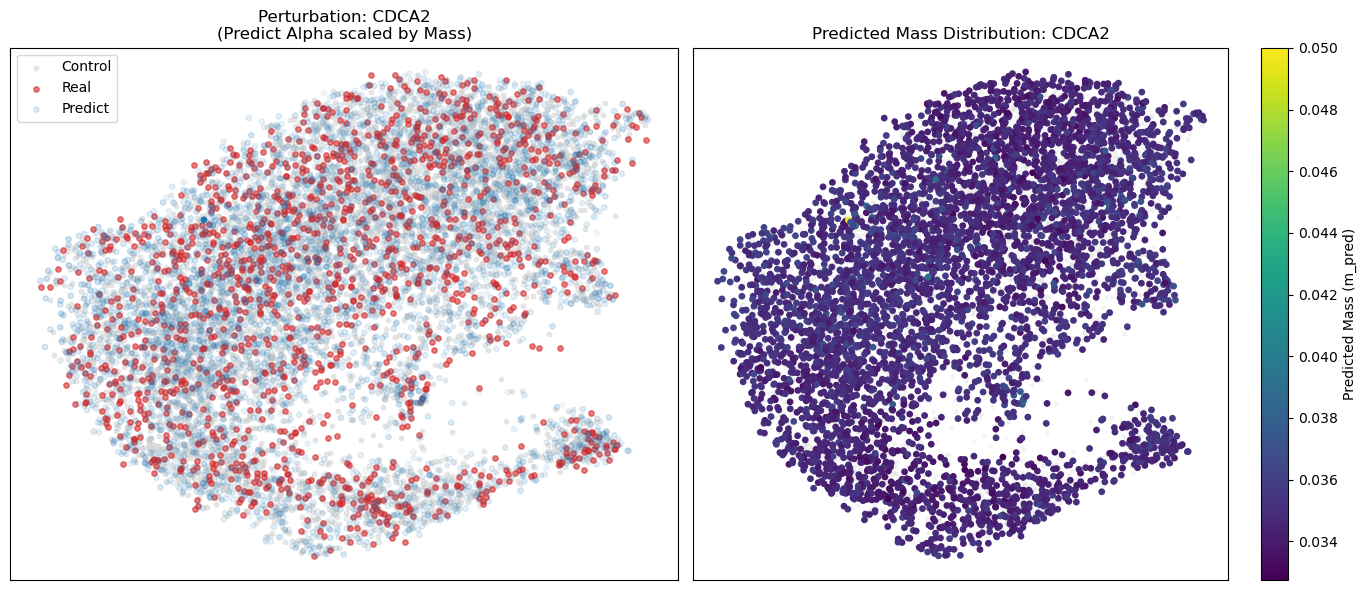

Plotting DHX36...


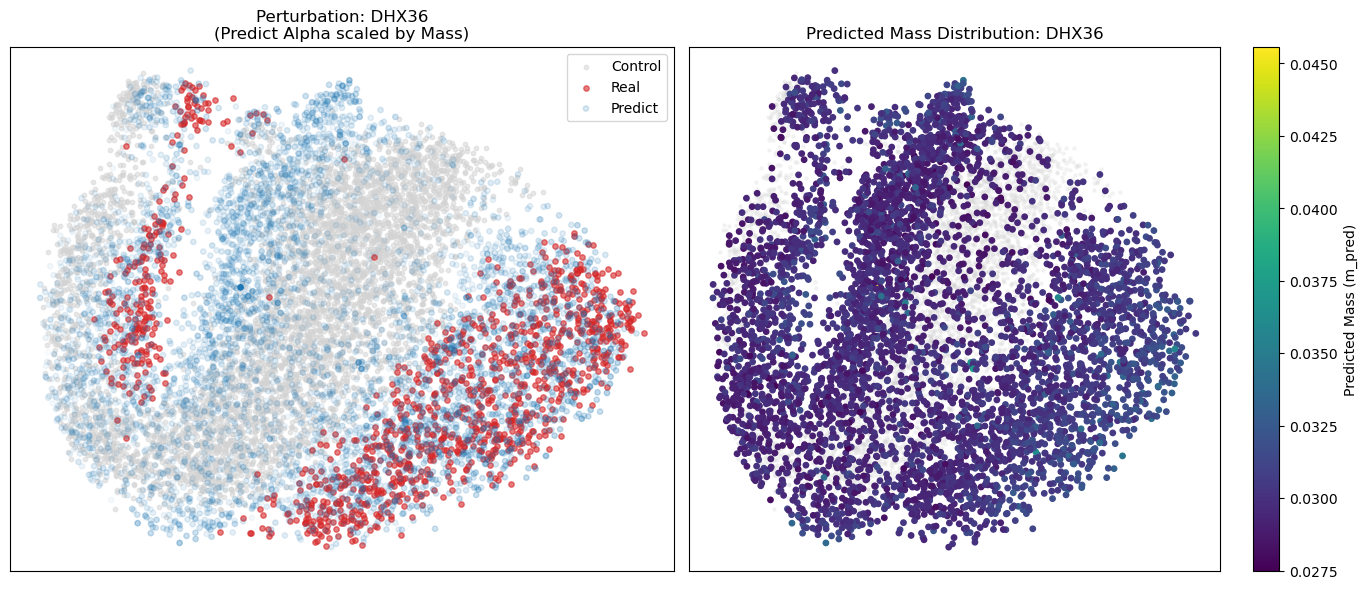

Plotting TMSB10...


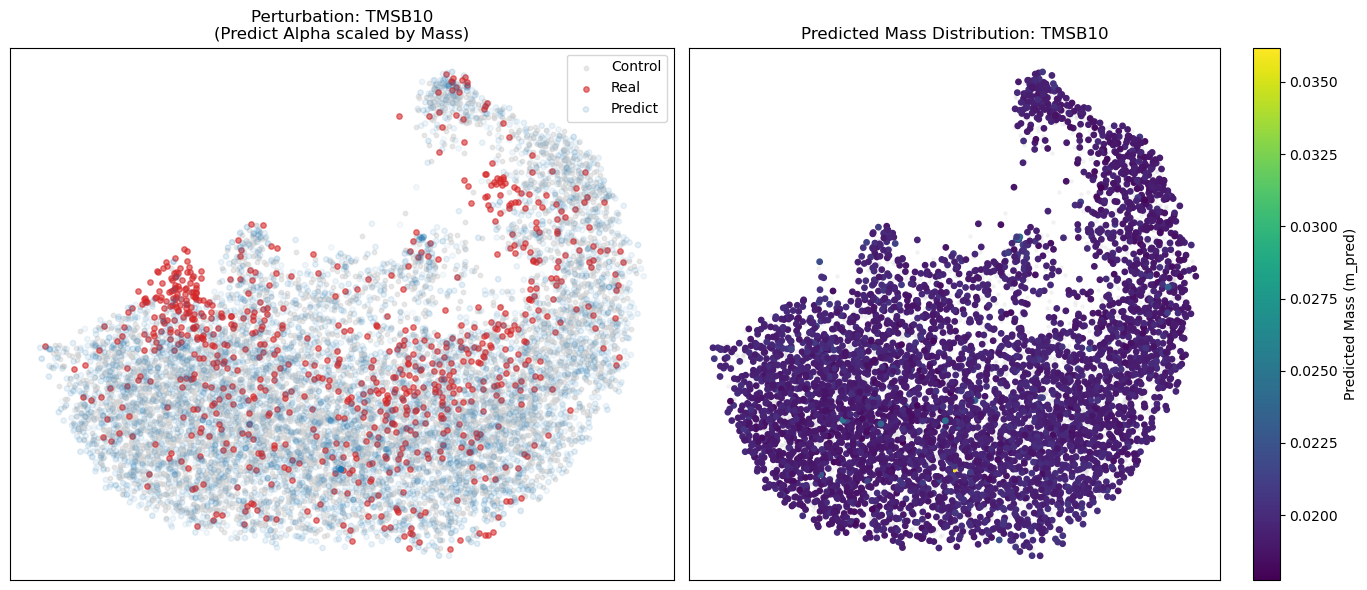

Plotting KAT2A...


KeyboardInterrupt: 

In [57]:
from src.evaluate import plot_perturbation_umap
plot_perturbation_umap(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_train, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

In [ ]:
plot_perturbation_umap(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_test, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

In [26]:
if sample_rep_scaled == "X_scVI":
    sc.pp.normalize_total(adata_control, target_sum=1e4)
    sc.pp.normalize_total(adata_train, target_sum=1e4)
    sc.pp.normalize_total(adata_test, target_sum=1e4)


# 可以使用以下函数复原，可以返回去掉batch信息后的归一化count
# 但是会导致返回的不再是一个稀疏矩阵，导致内存爆掉
# 应对方法可能有:只看某些基因等等
# temp = model_ref.get_normalized_expression(
#         adata=adata, 
#         library_size="latent", 
#         n_samples=10,         
#         return_mean=True,
#         transform_batch= ？？ 
#     )

--- Analyzing CDCA2 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['CDCA2', 'CHCHD2', 'TUBB2A', 'ZNF850', 'TAGLN']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


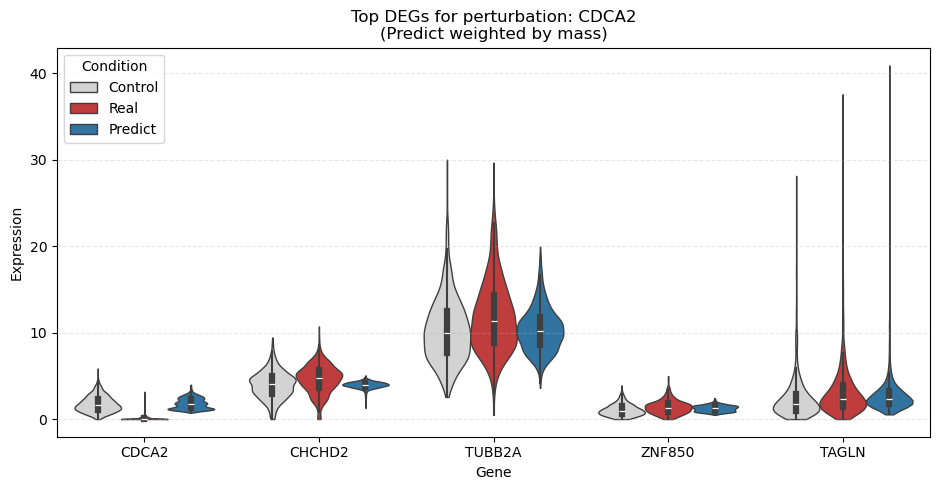

--- Analyzing DHX36 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['DHX36', 'RYBP', 'LDB1', 'MTA3', 'DYNLL2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


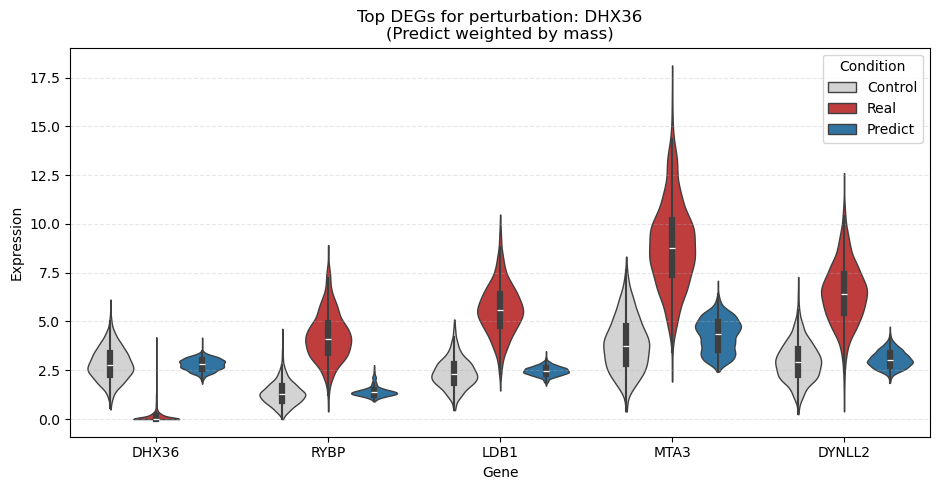

--- Analyzing TMSB10 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['TMSB10', 'ACTL8', 'ACSS2', 'MVD', 'HMGCS1']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


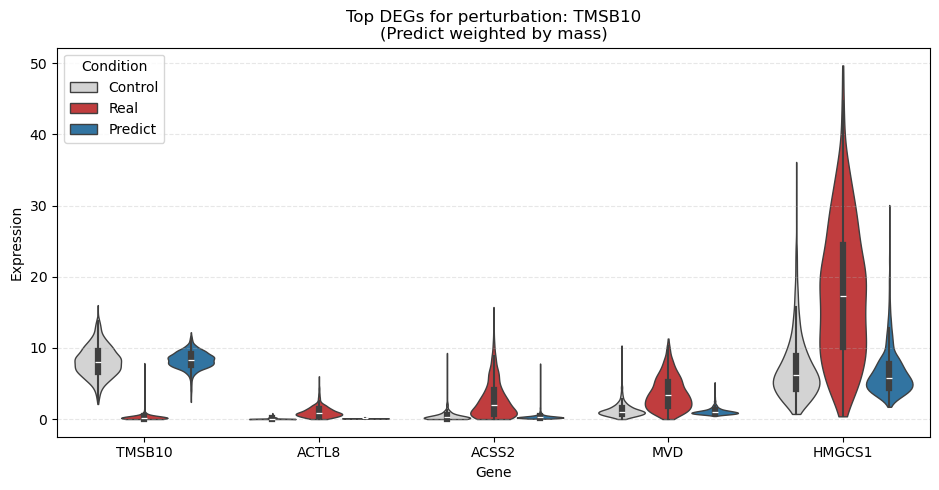

--- Analyzing KAT2A ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KAT2A', 'NODAL', 'ITGB5', 'CRABP2', 'PFDN2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


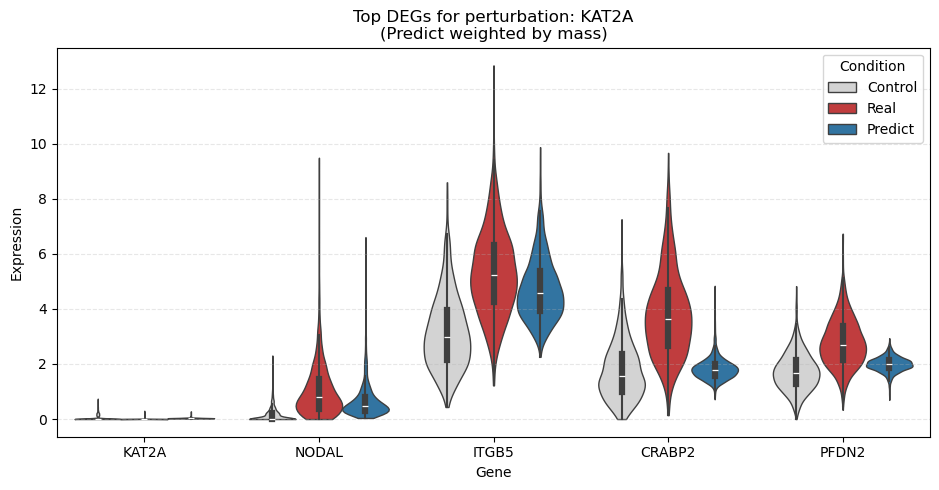

--- Analyzing PHF14 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['PHF14', 'CRABP2', 'RND2', 'NES', 'ABRACL']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


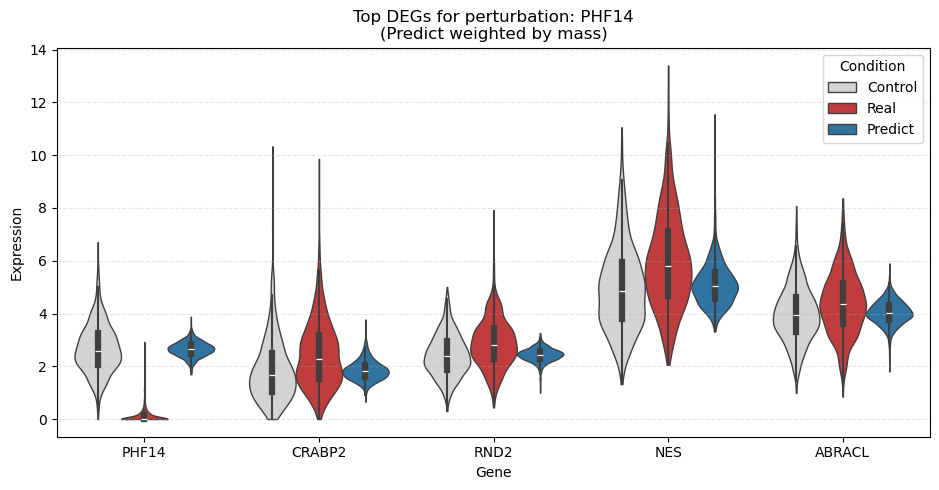

--- Analyzing KLF10 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KLF10', 'ALDH6A1', 'KLF15', 'HK2', 'ABAT']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


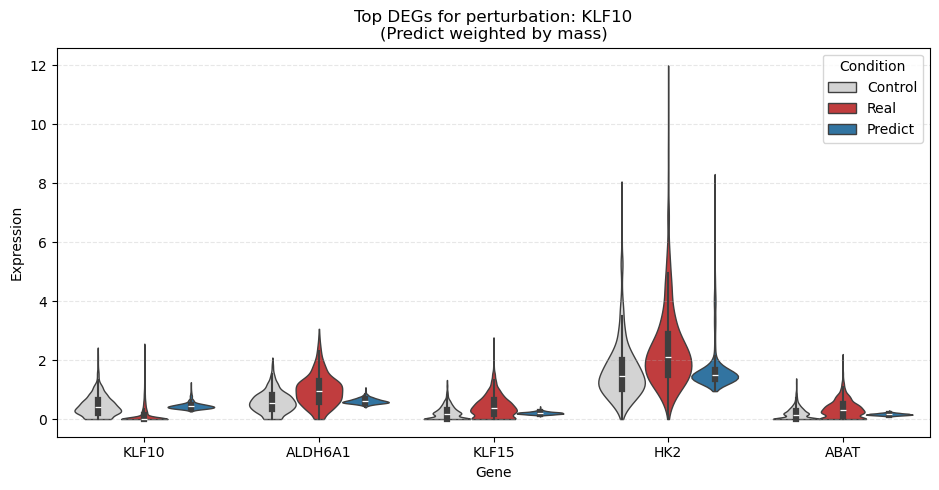

--- Analyzing KDM1A ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KDM1A', 'VIM', 'SPP1', 'NRK', 'APELA']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


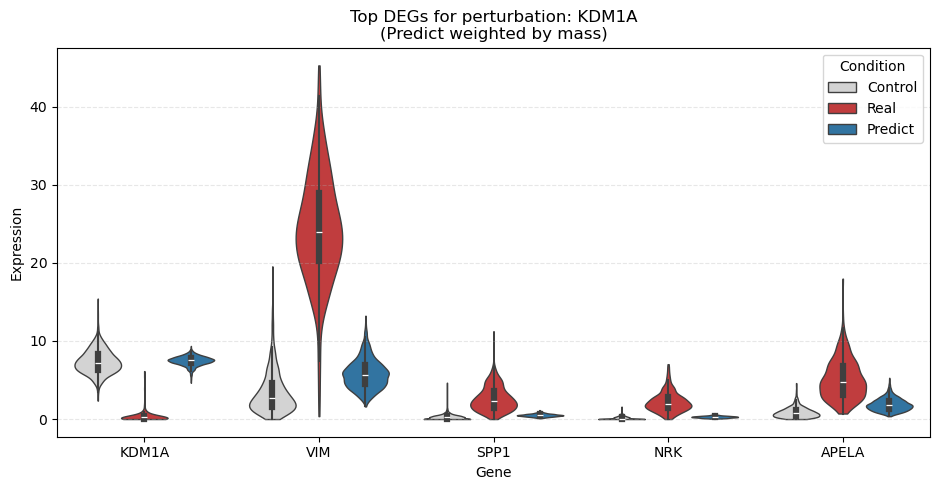

--- Analyzing STAT1 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['STAT1', 'GTPBP6', 'SLC38A7', 'NETO2', 'RSRP1']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


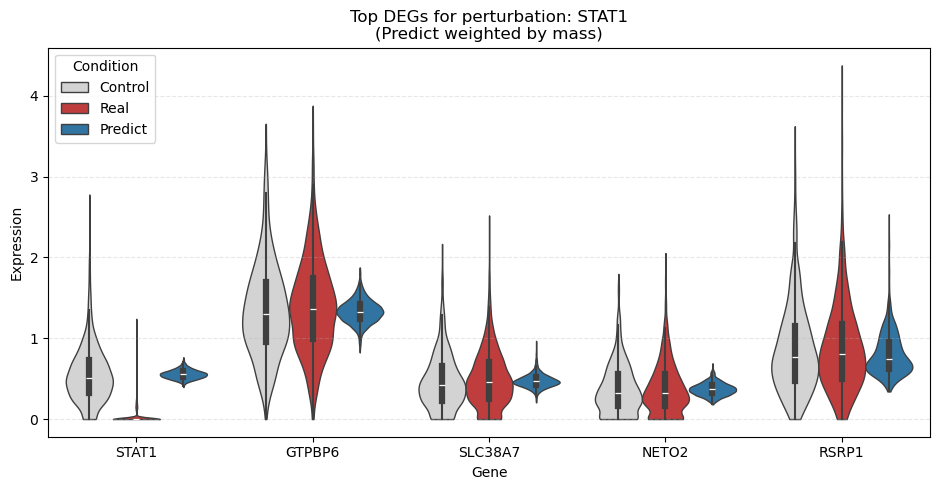

--- Analyzing ACAT2 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['ACAT2', 'MVD', 'CYB5B', 'SVBP', 'HMGCS1']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


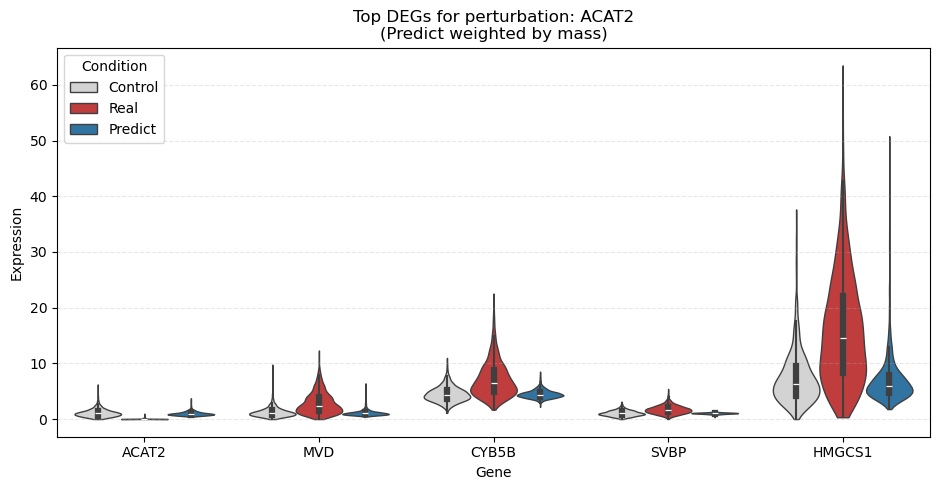

--- Analyzing STX4 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['STX4', 'POLR3G', 'EEF2', 'CRABP1', 'VAT1L']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


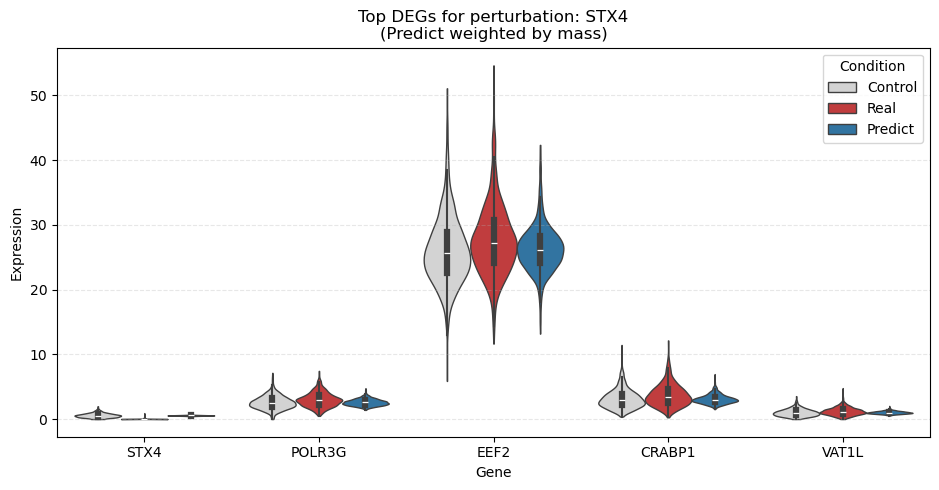

--- Analyzing HMGB2 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['HMGB2', 'PSAT1', 'MTHFD2', 'PCK2', 'DDIT4']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


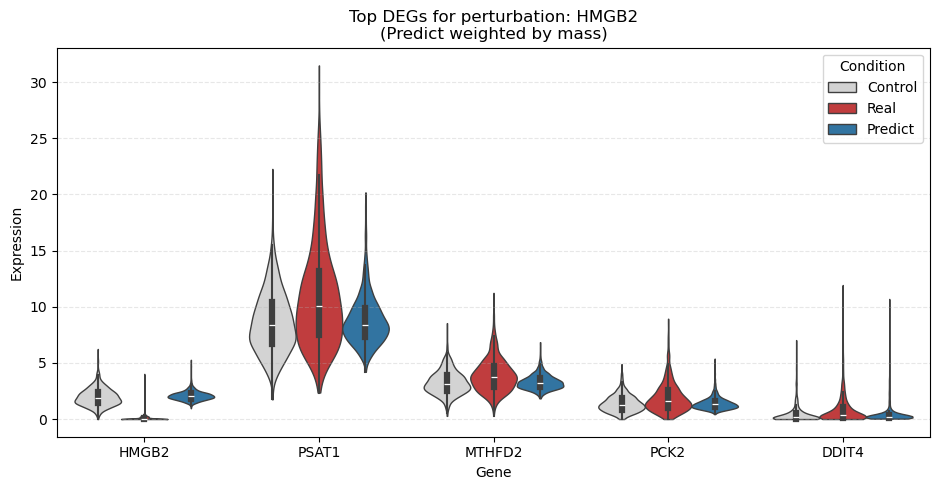

--- Analyzing TADA1 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['TADA1', 'CRABP2', 'ITGB5', 'NES', 'NODAL']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


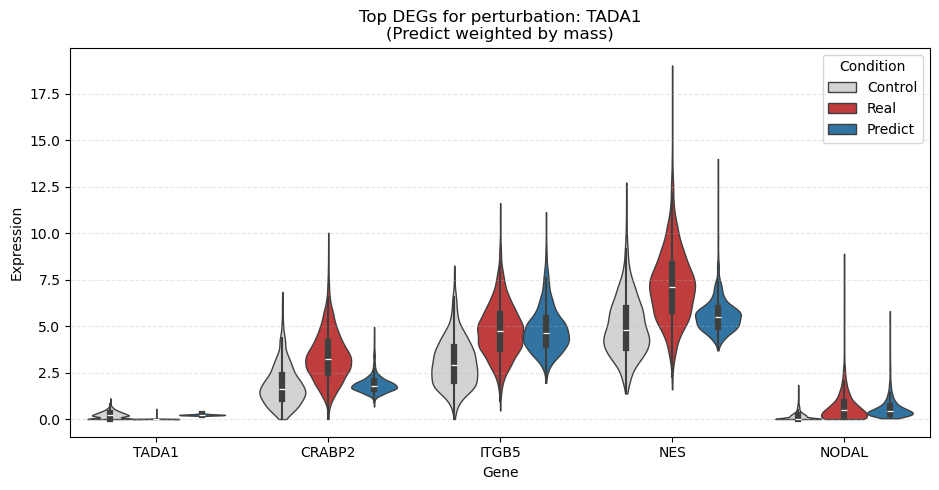

--- Analyzing MTA1 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['MTA1', 'CHCHD2', 'S100A13', 'OCIAD2', 'BAX']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


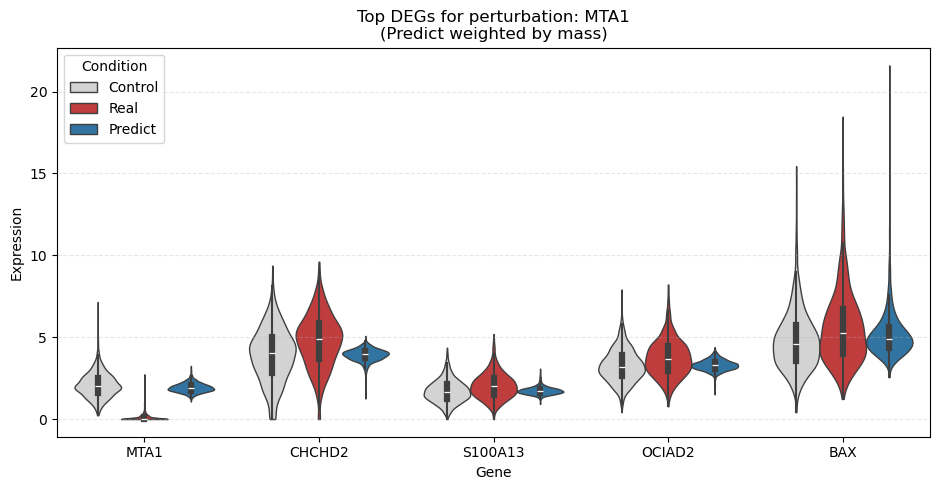

--- Analyzing C1QBP ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['C1QBP', 'OPN3', 'CHD7', 'FLVCR1', 'POLR2A']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


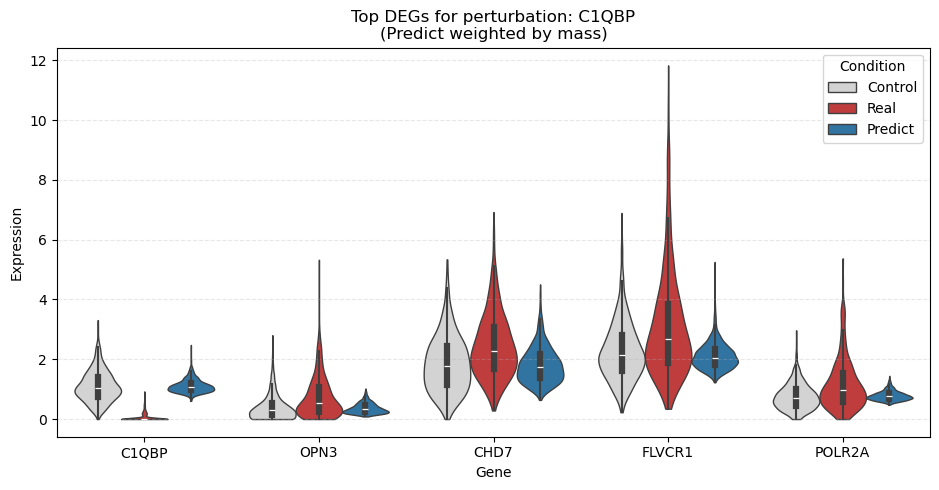

In [27]:
from src.evaluate import plot_top_degs_violin
for target in target_genes: # ['CDCA2', 'DHX36', 'TMSB10']
    plot_top_degs_violin(
        reconstructed_data=results_genes1,
        adata_control=adata_control,
        adata_real=adata_train,
        target_gene=target,
        top_n=4 # 展示 Target + Top 4 下游基因
    )

--- Analyzing CDCA2 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['CDCA2', 'GAL', 'ZNF850', 'DACT1', 'S100A10']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


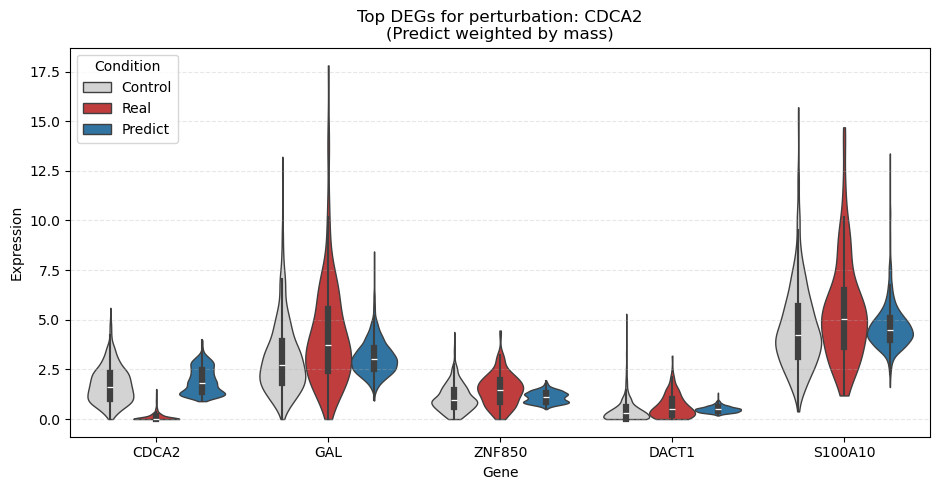

--- Analyzing DHX36 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['DHX36', 'LDB1', 'RYBP', 'DYNLL2', 'MTA3']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


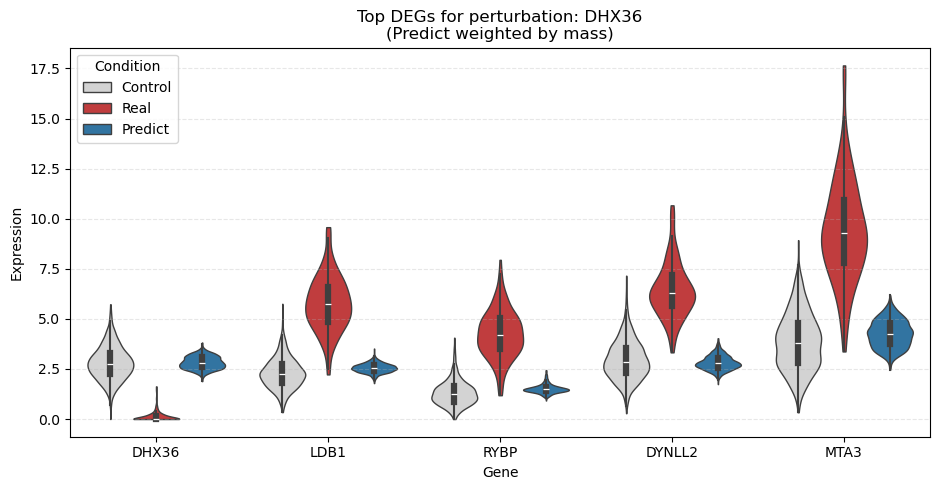

--- Analyzing TMSB10 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['TMSB10', 'ACTL8', 'HMGCS1', 'CYB5B', 'ERG28']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


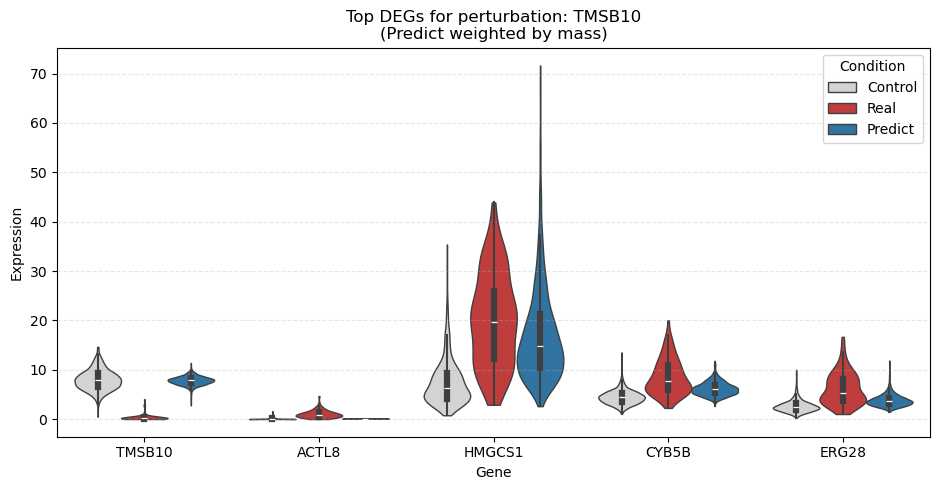

--- Analyzing KAT2A ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KAT2A', 'NODAL', 'ITGB5', 'OCIAD2', 'CRABP2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


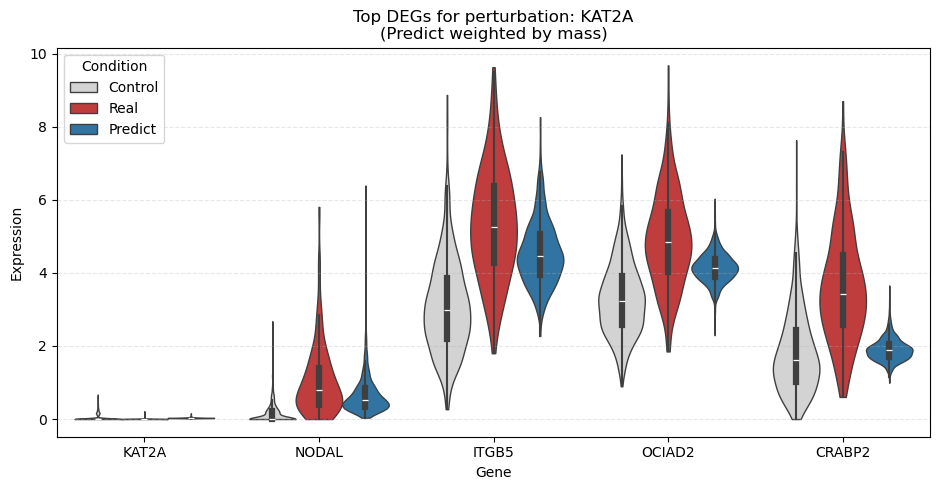

--- Analyzing PHF14 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['PHF14', 'RND2', 'CRABP2', 'NES', 'RASSF4']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


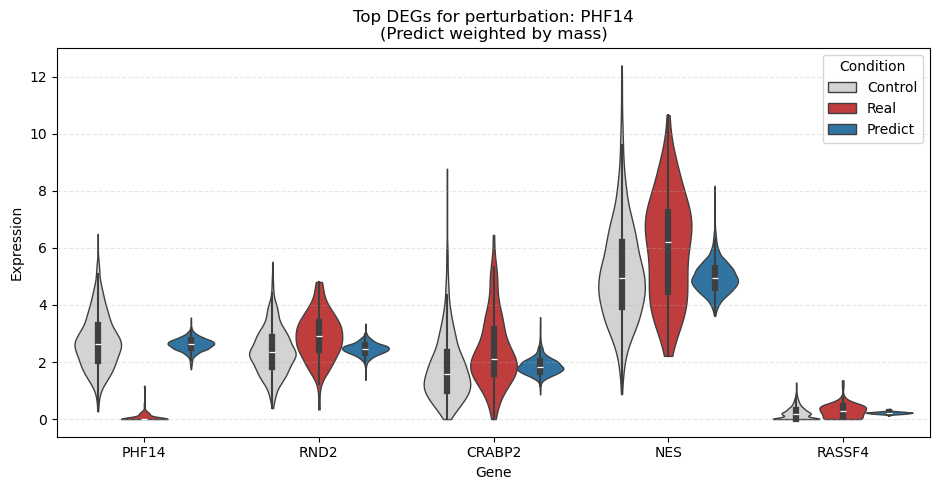

--- Analyzing KLF10 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KLF10', 'ALDH6A1', 'KLF15', 'HK2', 'ABAT']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


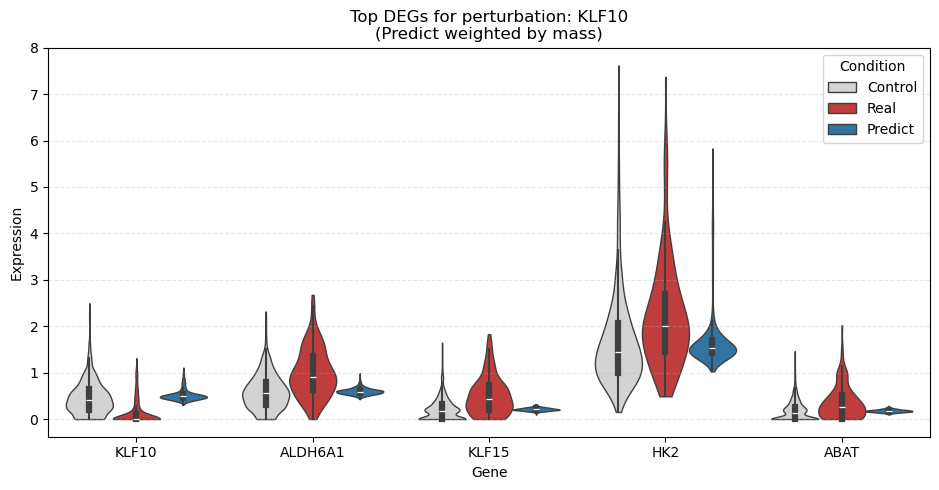

--- Analyzing KDM1A ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KDM1A', 'VIM', 'NRK', 'SPP1', 'APELA']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


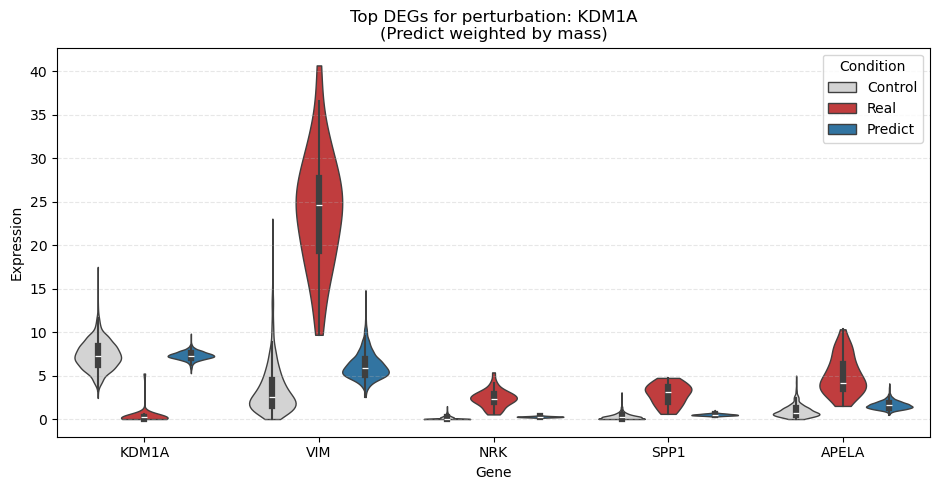

--- Analyzing STAT1 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['STAT1', 'SGO2', 'SKA1', 'HPRT1', 'CBR4']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


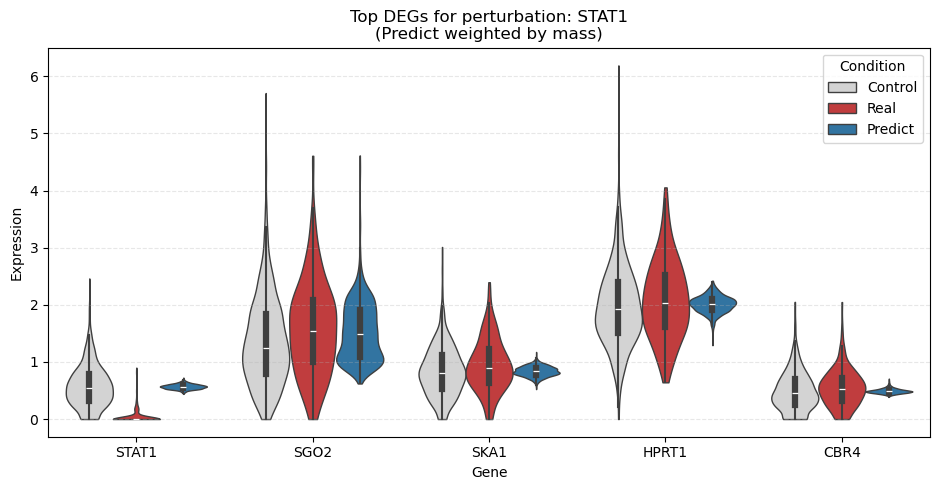

--- Analyzing ACAT2 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['ACAT2', 'CYB5B', 'MVD', 'HMGCS1', 'DHCR24']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


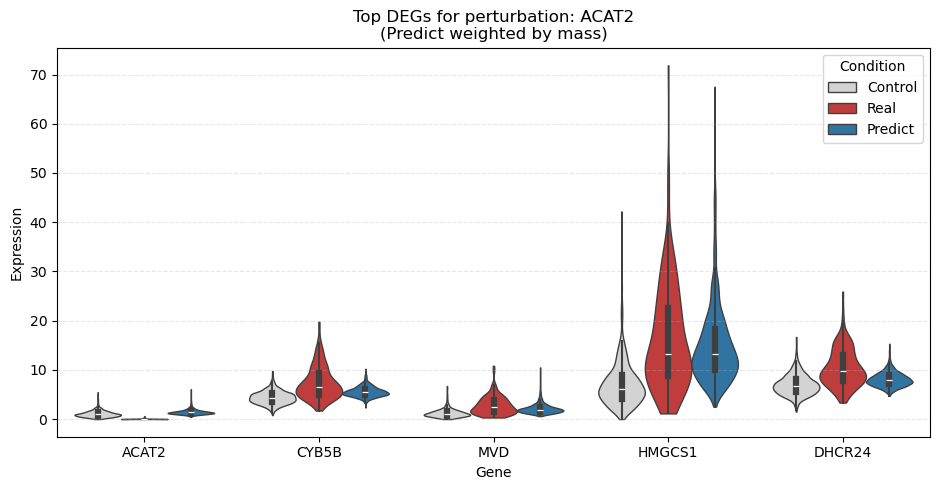

--- Analyzing STX4 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['STX4', 'FUT8', 'ACP6', 'MDK', 'ZMYM2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


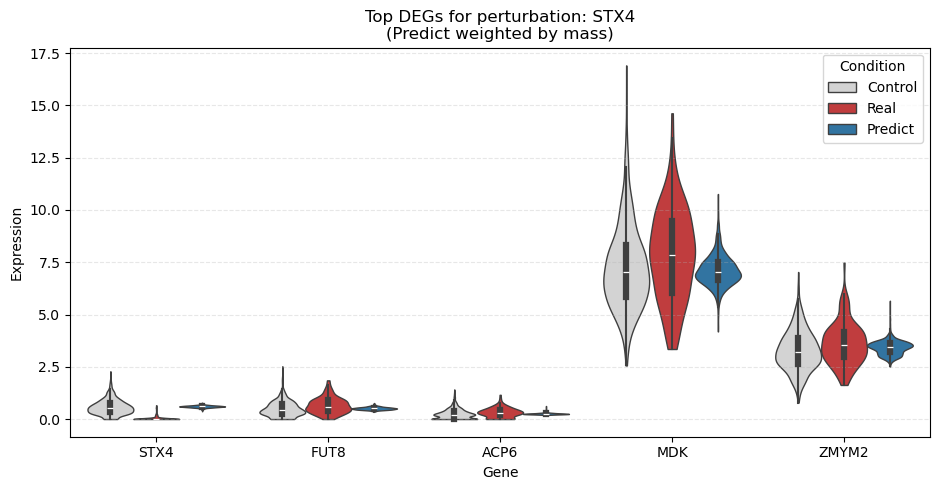

--- Analyzing HMGB2 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['HMGB2', 'SESN2', 'BBC3', 'PSAT1', 'MTHFD2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


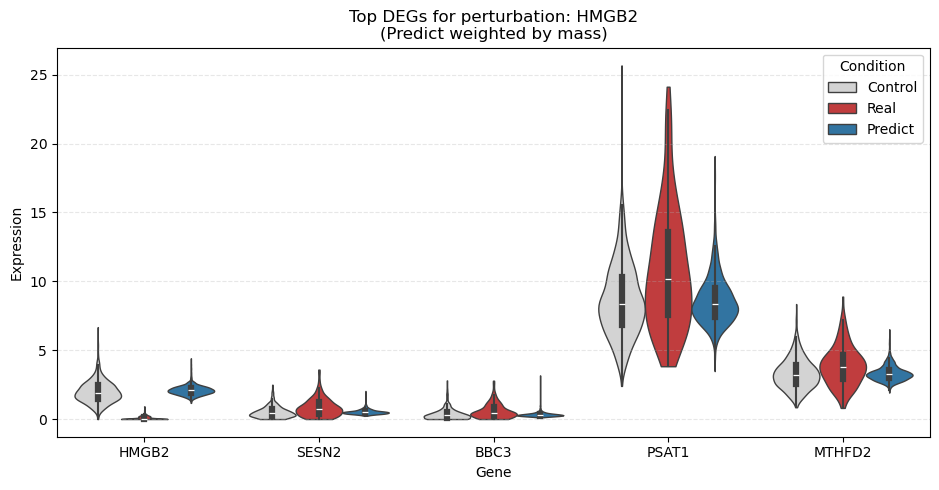

--- Analyzing TADA1 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['TADA1', 'CRABP2', 'ITGB5', 'MDFI', 'NES']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


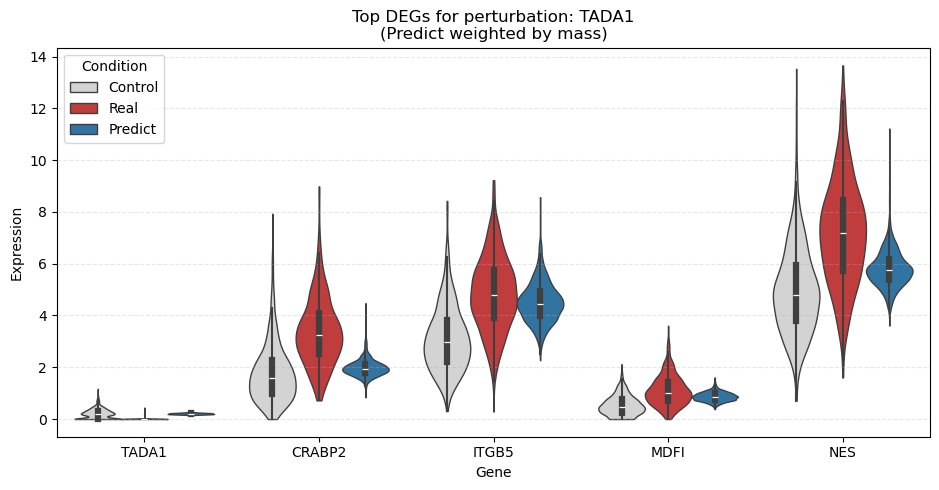

--- Analyzing MTA1 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['MTA1', 'CHCHD2', 'B2M', 'QARS', 'CKB']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


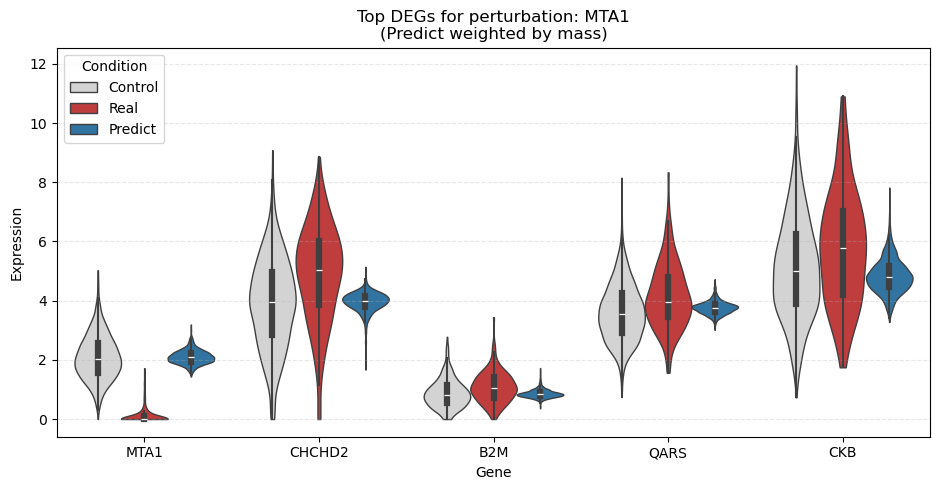

--- Analyzing C1QBP ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['C1QBP', 'OPN3', 'POLR2A', 'FLVCR1', 'AMOTL1']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


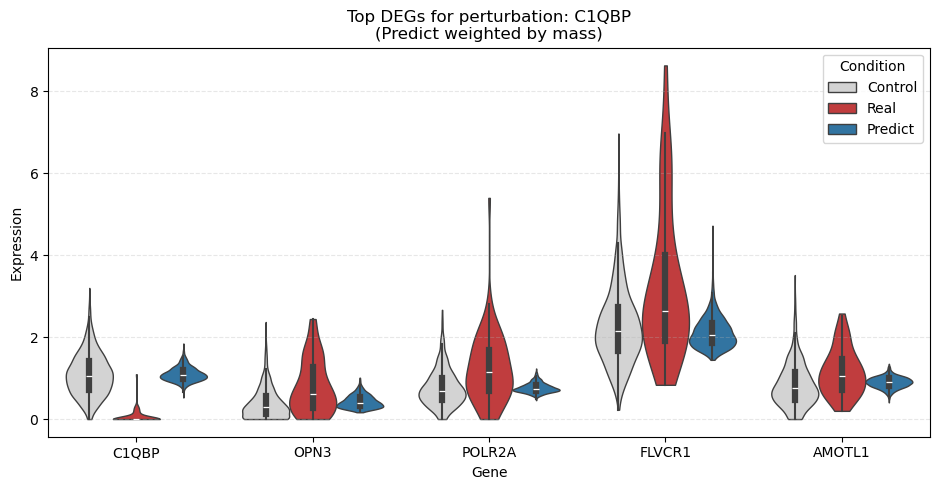

In [24]:
for target in target_genes: # ['CDCA2', 'DHX36', 'TMSB10']
    plot_top_degs_violin(
        reconstructed_data=results_genes1,
        adata_control=adata_control,
        adata_real=adata_test,
        target_gene=target,
        top_n=4 # 展示 Target + Top 4 下游基因
    )

=== Mass Statistics for CDCA2 prediction ===
Mean Mass: 0.0424
Max  Mass: 0.0465
Min  Mass: 0.0336
Std  Mass: 0.0005


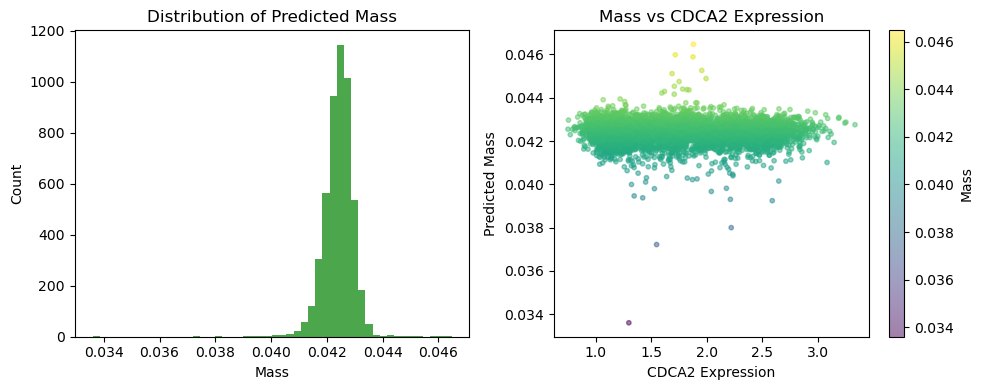

=== Mass Statistics for DHX36 prediction ===
Mean Mass: 0.0342
Max  Mass: 0.0471
Min  Mass: 0.0299
Std  Mass: 0.0018


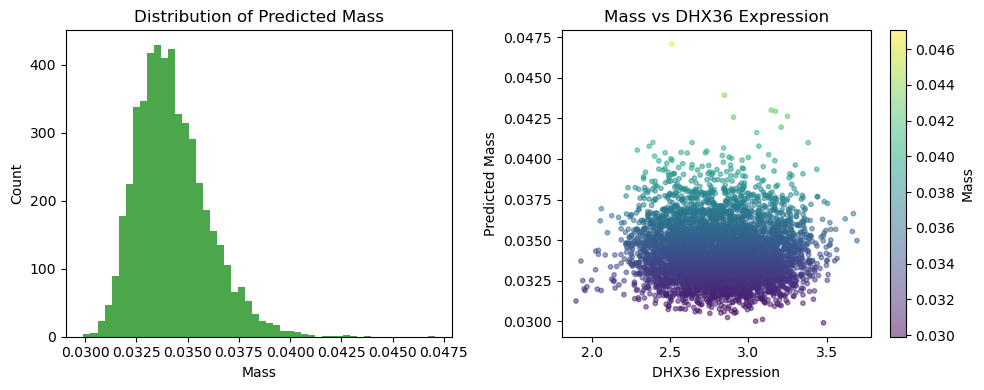

=== Mass Statistics for TMSB10 prediction ===
Mean Mass: 0.0219
Max  Mass: 0.0260
Min  Mass: 0.0174
Std  Mass: 0.0006


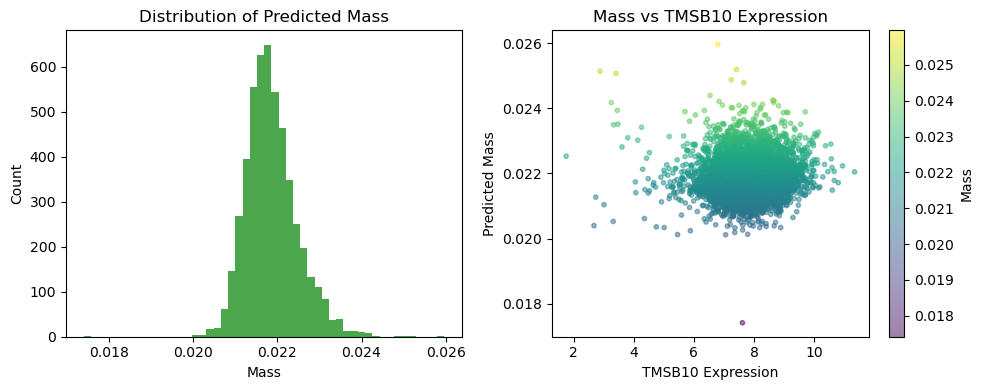

=== Mass Statistics for KAT2A prediction ===
Mean Mass: 0.0512
Max  Mass: 0.0600
Min  Mass: 0.0400
Std  Mass: 0.0022


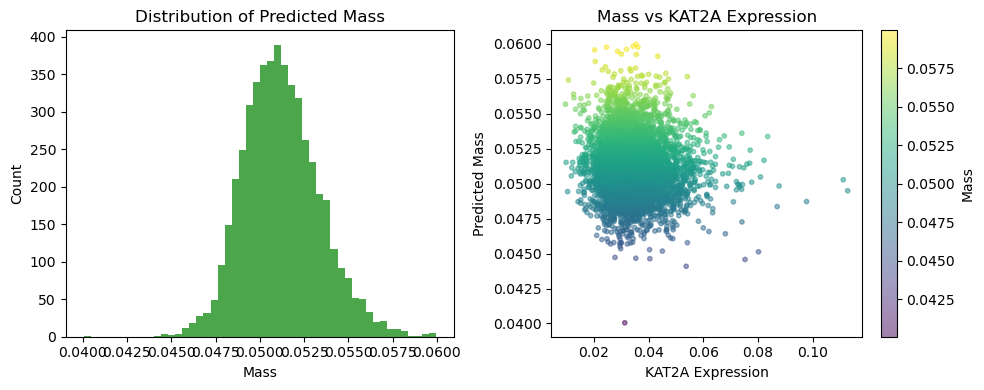

=== Mass Statistics for PHF14 prediction ===
Mean Mass: 0.0228
Max  Mass: 0.0255
Min  Mass: 0.0188
Std  Mass: 0.0003


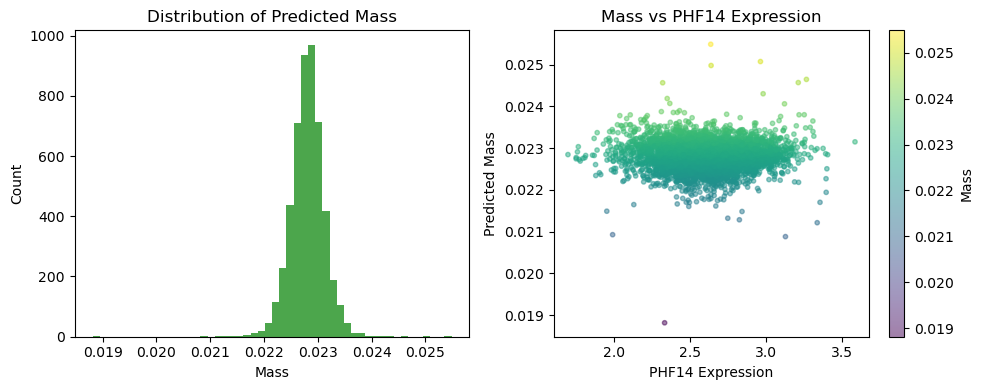

=== Mass Statistics for KLF10 prediction ===
Mean Mass: 0.0473
Max  Mass: 0.0526
Min  Mass: 0.0387
Std  Mass: 0.0006


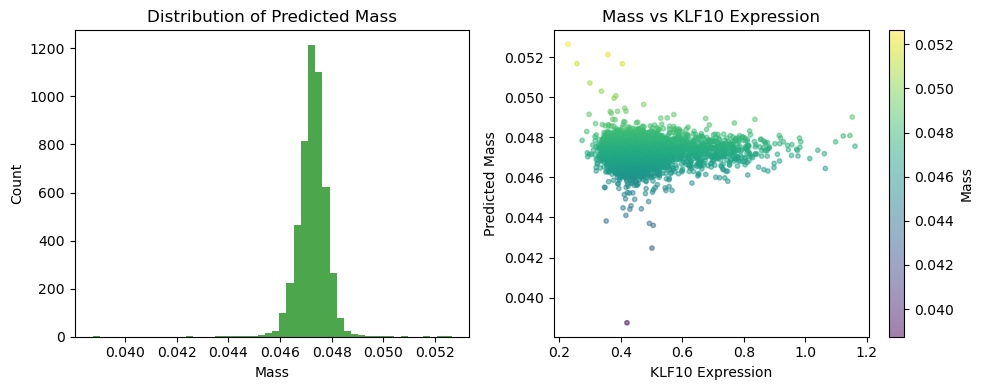

=== Mass Statistics for KDM1A prediction ===
Mean Mass: 0.0093
Max  Mass: 0.0137
Min  Mass: 0.0075
Std  Mass: 0.0006


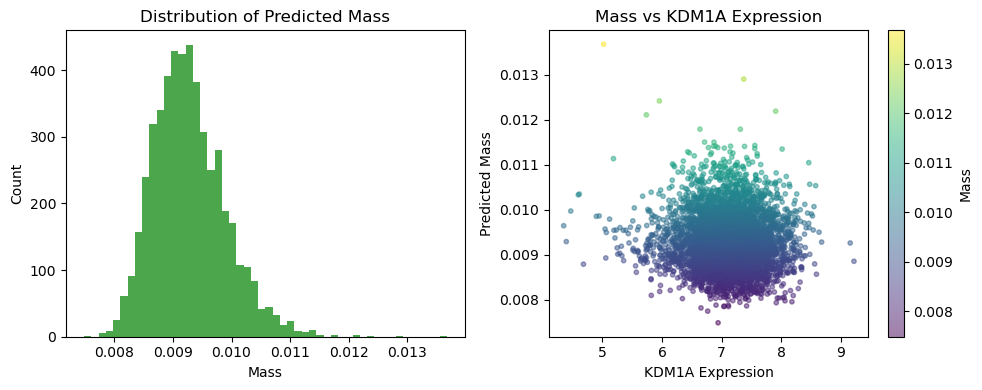

=== Mass Statistics for STAT1 prediction ===
Mean Mass: 0.0604
Max  Mass: 0.0672
Min  Mass: 0.0507
Std  Mass: 0.0007


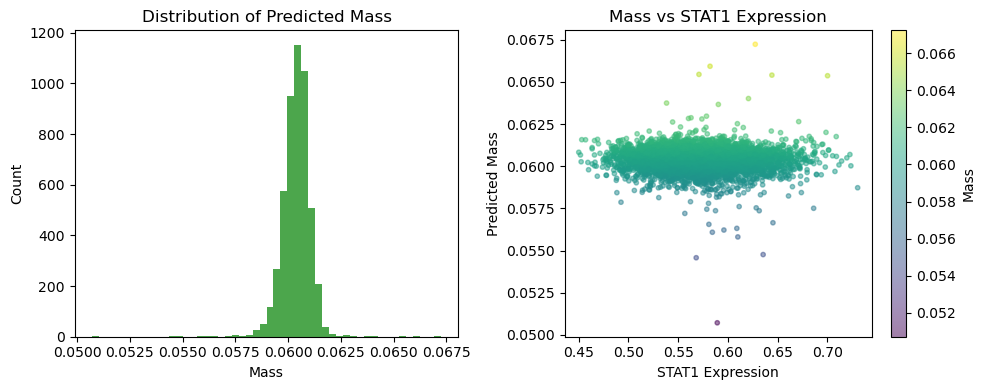

=== Mass Statistics for ACAT2 prediction ===
Mean Mass: 0.0429
Max  Mass: 0.0467
Min  Mass: 0.0317
Std  Mass: 0.0007


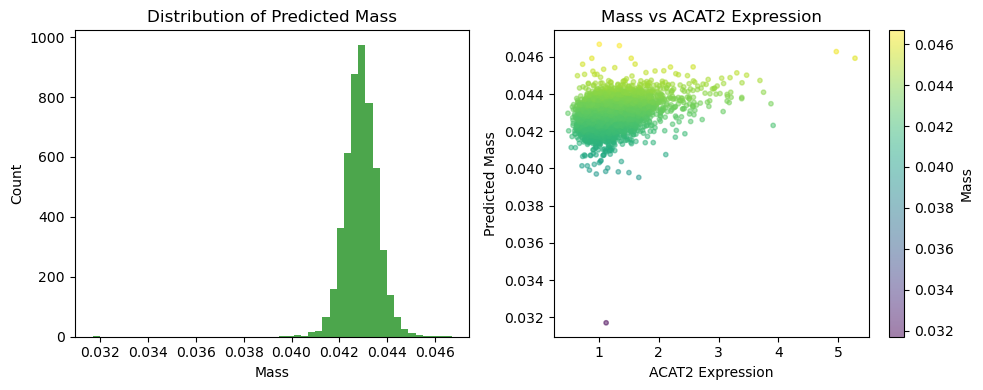

=== Mass Statistics for STX4 prediction ===
Mean Mass: 0.0310
Max  Mass: 0.0336
Min  Mass: 0.0257
Std  Mass: 0.0004


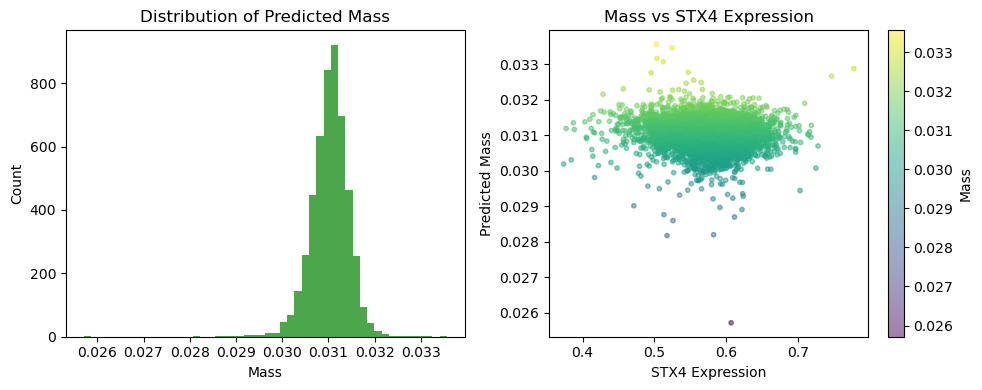

=== Mass Statistics for HMGB2 prediction ===
Mean Mass: 0.0366
Max  Mass: 0.0407
Min  Mass: 0.0338
Std  Mass: 0.0006


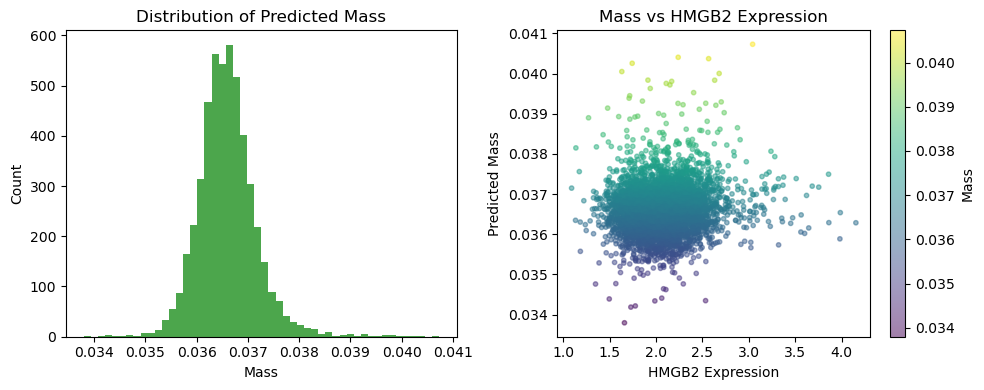

=== Mass Statistics for TADA1 prediction ===
Mean Mass: 0.0957
Max  Mass: 0.1132
Min  Mass: 0.0771
Std  Mass: 0.0037


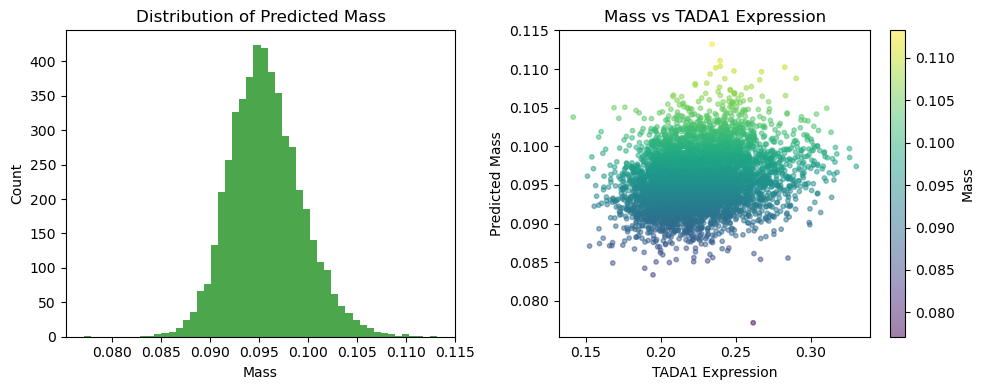

=== Mass Statistics for MTA1 prediction ===
Mean Mass: 0.0352
Max  Mass: 0.0386
Min  Mass: 0.0270
Std  Mass: 0.0005


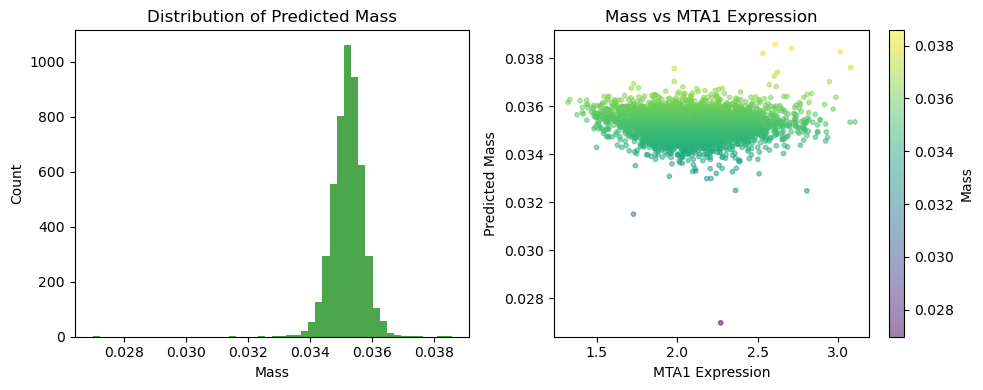

=== Mass Statistics for C1QBP prediction ===
Mean Mass: 0.0182
Max  Mass: 0.0209
Min  Mass: 0.0143
Std  Mass: 0.0003


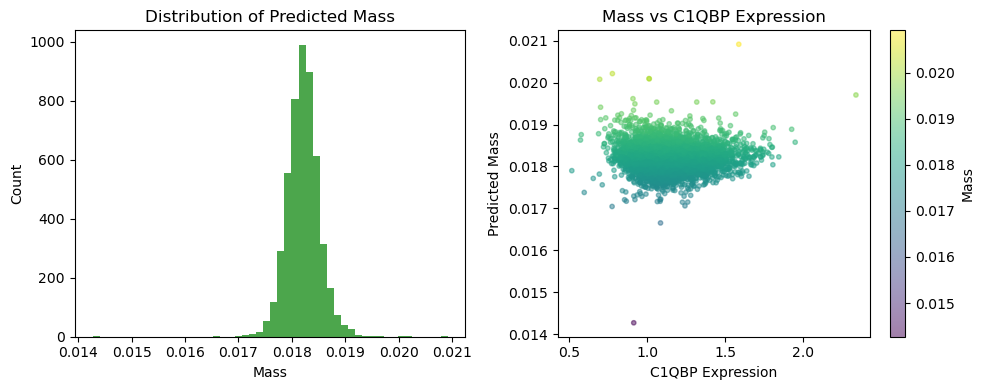

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)